In [ ]:
!pip install diffusers transformers accelerate peft bitsandbytes --quiet

In [4]:
import shutil
from pathlib import Path

# Find the Hugging Face cache directory
cache_dir = Path.home() / ".cache" / "huggingface"

if cache_dir.exists():
    print(f"Found cache directory at: {cache_dir}")
    try:
        shutil.rmtree(cache_dir)
        print("Successfully cleared the Hugging Face cache.")
    except Exception as e:
        print(f"Error clearing cache: {e}")
else:
    print("Cache directory not found (it may already be clear).")

Cache directory not found (it may already be clear).


In [ ]:
from huggingface_hub import notebook_login
notebook_login()

In [6]:
import os
from huggingface_hub import HfFolder
from accelerate import Accelerator
from diffusers import StableDiffusionPipeline, DDPMScheduler, UNet2DConditionModel
from peft import LoraConfig
from peft.utils import get_peft_model_state_dict
from torchvision import transforms
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
import torch
import bitsandbytes as bnb
from accelerate import Accelerator

# --- Load Pre-trained Models ---
MODEL_NAME = "stablediffusionapi/stable-diffusion-v1-5"
LORA_RANK = 16

from diffusers import StableDiffusionPipeline
import torch

print("Loading the complete Stable Diffusion pipeline...")

# This single command will download and correctly configure all necessary components,
# including the UNet, VAE, text encoder, and the problematic scheduler.
pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_NAME, 
    torch_dtype=torch.float16, # Use float16 for memory efficiency
    safety_checker=None, # Optional: disables the safety checker
    requires_safety_checker=False # Optional: disables the safety checker
)

# Move the pipeline to the GPU
accelerator = Accelerator(
    gradient_accumulation_steps=4,
    mixed_precision="no",
)
pipe = pipe.to(accelerator.device)

# Now, extract the components from the pre-loaded pipeline
unet = pipe.unet
vae = pipe.vae
text_encoder = pipe.text_encoder
tokenizer = pipe.tokenizer
noise_scheduler = pipe.scheduler 

# Freeze the weights for all but the LoRA layers
vae.requires_grad_(False)
text_encoder.requires_grad_(False)
unet.requires_grad_(False)

print("All components successfully loaded from the pipeline.")

# --- Configure and Add LoRA Layers ---
lora_config = LoraConfig(
    r=LORA_RANK, lora_alpha=LORA_RANK,
    target_modules=["to_k", "to_q", "to_v", "to_out.0"],
    lora_dropout=0.1, bias="none",
)
unet.add_adapter(lora_config)


2025-09-30 09:54:41.615903: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759226081.976486      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759226082.079625      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Loading the complete Stable Diffusion pipeline...


model_index.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

text_encoder/model.safetensors:   0%|          | 0.00/246M [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/601 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/transformers/models/clip/feature_extraction_clip.py:30: FutureWarning: The class CLIPFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use CLIPImageProcessor instead.
  warnings.warn(


All components successfully loaded from the pipeline.


In [ ]:
import os
from PIL import Image
from itertools import cycle
import torch
import bitsandbytes as bnb
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from diffusers.optimization import get_scheduler
from peft.utils import get_peft_model_state_dict
from safetensors.torch import save_file

DATASET_DIR = "/kaggle/input/royo-art-dataset/luis_royo_art"
OUTPUT_DIR = "royo_lora_output"
LEARNING_RATE = 1e-4
TRAIN_BATCH_SIZE = 1
MAX_TRAIN_STEPS = 2000
WEIGHT_DECAY = 1e-2
LR_SCHEDULER = "cosine"
LR_WARMUP_STEPS = 100

# Validation and Early Stopping Configuration
VALIDATION_SPLIT_PERCENTAGE = 10
VALIDATION_STEPS = 50
PATIENCE = 10

# --- Custom Dataset for images ---
class DreamBoothDataset(Dataset):
    def __init__(self, instance_data_root, size=512):
        self.instance_data_root = instance_data_root
        self.image_paths = [os.path.join(self.instance_data_root, f) for f in os.listdir(self.instance_data_root) if f.endswith(('png', 'jpg', 'jpeg'))]
        self.num_instance_images = len(self.image_paths)
        self.size = size
        self.transform = transforms.Compose([
            transforms.Resize(size),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.CenterCrop(size),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]),
        ])

    def __len__(self):
        return self.num_instance_images

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx % self.num_instance_images])
        if not image.mode == "RGB":
            image = image.convert("RGB")
        return {"instance_images": self.transform(image)}

# Split the dataset into training and validation sets
full_dataset = DreamBoothDataset(DATASET_DIR)
val_size = int(len(full_dataset) * (VALIDATION_SPLIT_PERCENTAGE / 100))
train_size = len(full_dataset) - val_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_dataloader = DataLoader(train_dataset, batch_size=TRAIN_BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=TRAIN_BATCH_SIZE, shuffle=False)

# --- Set up the Optimizer ---
optimizer = bnb.optim.AdamW8bit(
    unet.parameters(),
    lr=LEARNING_RATE,
    betas=(0.9, 0.999),
    weight_decay=WEIGHT_DECAY,
    eps=1e-8,
)

# --- Learning Rate Scheduler ---
lr_scheduler = get_scheduler(
    LR_SCHEDULER,
    optimizer=optimizer,
    num_warmup_steps=LR_WARMUP_STEPS * accelerator.gradient_accumulation_steps,
    num_training_steps=MAX_TRAIN_STEPS * accelerator.gradient_accumulation_steps,
)

# --- Prepare for Training with Accelerator ---
unet, optimizer, train_dataloader, val_dataloader, lr_scheduler = accelerator.prepare(
    unet, optimizer, train_dataloader, val_dataloader, lr_scheduler
)

best_val_loss = float('inf')
early_stopping_counter = 0

print("Starting LoRA training...")
with torch.no_grad():
    prompt_ids = tokenizer("", padding="max_length", max_length=tokenizer.model_max_length, truncation=True, return_tensors="pt").input_ids
    blank_text_embeds = text_encoder(prompt_ids.to(accelerator.device))[0]
    
for step, batch in enumerate(cycle(train_dataloader)):
    if step >= MAX_TRAIN_STEPS:
        break

    unet.train()
    with accelerator.accumulate(unet):
        latents = vae.encode(batch["instance_images"].to(accelerator.device, dtype=torch.float16)).latent_dist.sample() * vae.config.scaling_factor
        noise = torch.randn_like(latents)
        bsz = latents.shape[0]
        timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (bsz,), device=latents.device).long()
        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

        noise_pred = unet(noisy_latents, timesteps, blank_text_embeds).sample
        loss = torch.nn.functional.mse_loss(noise_pred.float(), noise.float(), reduction="mean")

        accelerator.backward(loss)
        if accelerator.sync_gradients:
            accelerator.clip_grad_norm_(unet.parameters(), 1.0)
            #pass
        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()

    if accelerator.is_main_process and step % 10 == 0:
        print(f"Step {step}/{MAX_TRAIN_STEPS}, Train Loss: {loss.detach().item()}, LR: {lr_scheduler.get_last_lr()[0]}")

    if accelerator.is_main_process and (step + 1) % VALIDATION_STEPS == 0:
        unet.eval()
        val_loss_total = 0
        with torch.no_grad():
            for val_batch in val_dataloader:
                latents = vae.encode(val_batch["instance_images"].to(accelerator.device, dtype=torch.float16)).latent_dist.sample() * vae.config.scaling_factor
                noise = torch.randn_like(latents)
                bsz = latents.shape[0]
                timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (bsz,), device=latents.device).long()
                noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)
                noise_pred = unet(noisy_latents, timesteps, blank_text_embeds).sample
                val_loss = torch.nn.functional.mse_loss(noise_pred.float(), noise.float(), reduction="mean")
                val_loss_total += val_loss.item()

        avg_val_loss = val_loss_total / len(val_dataloader)
        print(f"--- Step {step+1}, Validation Loss: {avg_val_loss} ---")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            early_stopping_counter = 0
            print(f"  -> New best model found! Saving to {OUTPUT_DIR}")
            unwrapped_unet = accelerator.unwrap_model(unet)
            lora_state_dict = get_peft_model_state_dict(unwrapped_unet)
            unet_lora_state_dict = {f"unet.{key}": value for key, value in lora_state_dict.items()}
            lora_save_path = os.path.join(OUTPUT_DIR, "pytorch_lora_weights.safetensors")
            os.makedirs(OUTPUT_DIR, exist_ok=True)
            save_file(unet_lora_state_dict, lora_save_path)
        else:
            early_stopping_counter += 1
            print(f"  -> No improvement. Counter: {early_stopping_counter}/{PATIENCE}")

    if early_stopping_counter >= PATIENCE:
        print(f"Early stopping triggered after {PATIENCE} validation checks with no improvement.")
        break

print(f"Training finished. Best model saved to {OUTPUT_DIR}")

In [14]:
# weights file check

from safetensors import safe_open
import os

LORA_FILE_PATH = "royo_lora_output/pytorch_lora_weights.safetensors"

try:
    with safe_open(LORA_FILE_PATH, framework="pt", device="cpu") as f:
        print("Successfully opened the LoRA file.")
        
        # Get the list of all layer names (keys)
        keys = list(f.keys())
        
        print(f"Found {len(keys)} layers in the file.")
        
        if keys:
            print("\nHere's a sample of the first 5 layer names:")
            for key in keys[:5]:
                print(key)

except Exception as e:
    print(f"Error opening or reading the file: {e}")

Successfully opened the LoRA file.
Found 256 layers in the file.

Here's a sample of the first 5 layer names:
unet.down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_k.lora_A.weight
unet.down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_k.lora_B.weight
unet.down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_out.0.lora_A.weight
unet.down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_out.0.lora_B.weight
unet.down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_q.lora_A.weight


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


Model and LoRA are ready on the GPU.

Generating image for prompt: 'a medieval beautiful redhead fantasy girl with a sword, masterpiece, art by Luis Royo'


  0%|          | 0/50 [00:00<?, ?it/s]

Image generated and saved as 'royo_style_output.png'


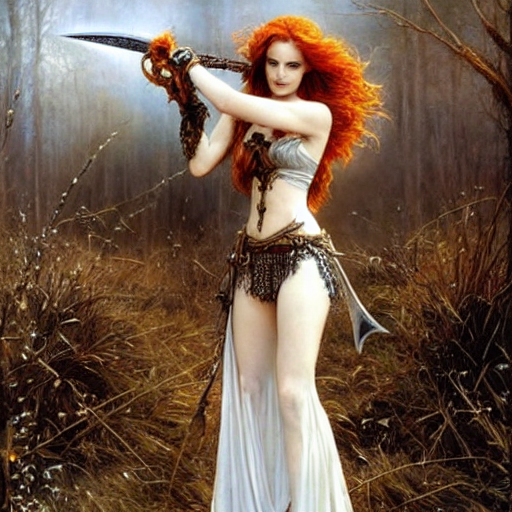

In [16]:
import torch
from diffusers import StableDiffusionPipeline

MODEL_NAME = "stablediffusionapi/stable-diffusion-v1-5" 
LORA_PATH = "./royo_lora_output" 

# --- Load the Model and LoRA ---
pipe = StableDiffusionPipeline.from_pretrained(MODEL_NAME, torch_dtype=torch.float16)
pipe.load_lora_weights(LORA_PATH)

# Move the entire pipeline to the GPU
pipe = pipe.to("cuda")
print("Model and LoRA are ready on the GPU.")

# --- Generate an Image ---
prompt = "a medieval beautiful redhead fantasy girl with a sword, masterpiece, art by Luis Royo"
# Use a negative prompt to guide the model away from common issues
negative_prompt = "ugly, deformed, disfigured, poor details, bad anatomy, worst quality, low quality, blurry, noisy"

print(f"\nGenerating image for prompt: '{prompt}'")

# Generate the image
# guidance_scale controls how much the model follows the prompt (7-8 is a good range)
# num_inference_steps controls the quality (more steps is often better, 30-50 is common)
image = pipe(
    prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=50,
    guidance_scale=7.5
).images[0]

output_filename = "royo_style_output.png"
image.save(output_filename)

print(f"Image generated and saved as '{output_filename}'")

from IPython.display import display
display(image)